In [8]:
from langchain_ollama import ChatOllama

In [9]:
llm = ChatOllama(
    model="mistral:7b",
    temperature=0.3
)

In [10]:
# defining state Schema
from typing import TypedDict
class graph_schema(TypedDict):
    name: str
    message: str

In [11]:
def welcome_node(state: graph_schema) -> graph_schema:
    curr_name = state["name"]
    curr_msg = state["message"]
    
    res = llm.invoke(f"My name is {curr_name} and I want to say {curr_msg}").content
    
    state["message"] = res
    return state

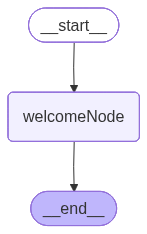

In [20]:
# creating the state graph
from langgraph.graph import StateGraph, START, END
graph = StateGraph(graph_schema)


# adding node to the graph.
graph.add_node("welcomeNode", welcome_node)

# defining the edge between the nodes.
graph.add_edge(START, "welcomeNode")
graph.add_edge("welcomeNode", END)

#compiling the graph.
compiled_graph = graph.compile()

from IPython.display import display, Image

Image(compiled_graph.get_graph().draw_mermaid_png())

In [19]:
if __name__ == "__main__":
    init_state = {
        "name": "Mohit Soni",
        "message": "Tell me about what is GenAI?"
    }
    
    final_res = compiled_graph.invoke(init_state)
    print(final_res["message"])

 GenAI, or General Artificial Intelligence, refers to a type of artificial intelligence that possesses the ability to understand, learn, and apply knowledge across a broad range of tasks and contexts. Unlike narrow AI, which is designed to perform a specific task, General AI can perform any intellectual task that a human being can do. It can learn from experience, adapt to new inputs, and even exhibit human-like intelligence in its problem-solving and decision-making abilities. However, it's important to note that as of now, General AI is still a concept in the realm of AI research and development, and no system has yet been developed that can truly be considered General AI.
